In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost
from xgboost import plot_tree, to_graphviz
import holidays as hdays


df = pd.read_excel('caffe_change.xlsx')

In [51]:
holidays = hdays.IN()
df['Is_holiday'] = df['Date'].apply(lambda x: 1 if x in holidays else 0)

In [52]:
df['Date'] = pd.to_datetime(df['Date'])

daily = (df.groupby('Date')
                   .agg({
                       'Quantity': 'sum',
                       'Total': 'sum',
                       'Weekday': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units', 'Total': 'Total_Sales'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Weekday"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Weekday"] = daily["Weekday"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
daily["Month"] = daily["Date"].dt.month
daily["Year"] = daily["Date"].dt.year

daily.head(400)

,Date,Total_Units,Total_Sales,Weekday,Week number,Day,Month,Year
0,2010-04-01,434,77066.51,3,13,1,4,2010
1,2010-04-02,489,88423.17,4,13,2,4,2010
2,2010-04-03,766,140314.76,5,13,3,4,2010
3,2010-04-04,467,86284.74,6,13,4,4,2010
4,2010-04-05,385,75674.14,0,14,5,4,2010
...,...,...,...,...,...,...,...,...
360,2011-03-27,441,90777.48,6,12,27,3,2011
361,2011-03-28,401,86109.16,0,13,28,3,2011
362,2011-03-29,447,87893.02,1,13,29,3,2011
363,2011-03-30,707,141621.87,2,13,30,3,2011


In [53]:
X_data, Y_data = daily.drop(columns=["Total_Units", "Date"]), daily["Total_Units"]

In [54]:
x_train, x_test = X_data[:250], X_data[250:]
y_train, y_test = Y_data[:250], Y_data[250:]

In [55]:
xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))

XGBoost Model Performance:
R^2 Score: 0.7868920564651489
Mean Absolute Error: 38.08171844482422
Mean Squared Error: 2396.255126953125


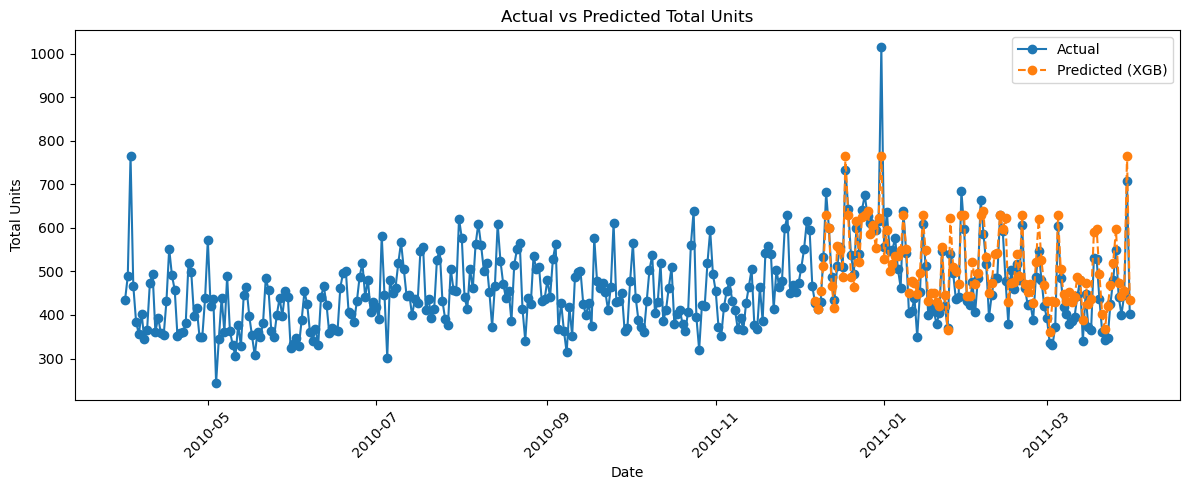

In [ ]:
# plot actual vs predicted for the test set
dates = daily['Date'].iloc[250:]  # test dates
plt.figure(figsize=(12,5))
plt.plot(daily["Date"], daily["Total_Units"], label='Actual', marker='o', linestyle='-')
plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Units')
plt.title('Actual vs Predicted Total Units')
plt.legend()
plt.xlim(dates.min(), dates.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
daily = (df.groupby(['Date', 'Category'], )
                   .agg({
                       'Quantity': 'sum',
                       'Total': 'sum',
                       'Weekday': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units', 'Total': 'Total_Sales'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Weekday"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Weekday"] = daily["Weekday"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
daily["Month"] = daily["Date"].dt.month
daily["Year"] = daily["Date"].dt.year

daily.head(20)

,Date,Category,Total_Units,Total_Sales,Weekday,Week number,Day,Month,Year
0,2010-04-01,ADD-ONS,8,185.62,3,13,1,4,2010
1,2010-04-01,BEVERAGE,137,13451.81,3,13,1,4,2010
2,2010-04-01,FOOD,175,27751.13,3,13,1,4,2010
3,2010-04-01,LIQUOR,27,3806.25,3,13,1,4,2010
4,2010-04-01,MERCHANDISE,3,387.00,3,13,1,4,2010
5,2010-04-01,TOBACCO,82,31264.20,3,13,1,4,2010
6,2010-04-01,WINES,2,220.50,3,13,1,4,2010
14,2010-04-02,WINES,3,3087.00,4,13,2,4,2010
13,2010-04-02,TOBACCO,80,30386.40,4,13,2,4,2010
12,2010-04-02,MISC,1,123.75,4,13,2,4,2010


Category: ADD-ONS
XGBoost Model Performance:
R^2 Score: 0.6828131675720215
Mean Absolute Error: 1.8836740255355835
Mean Squared Error: 4.656860828399658




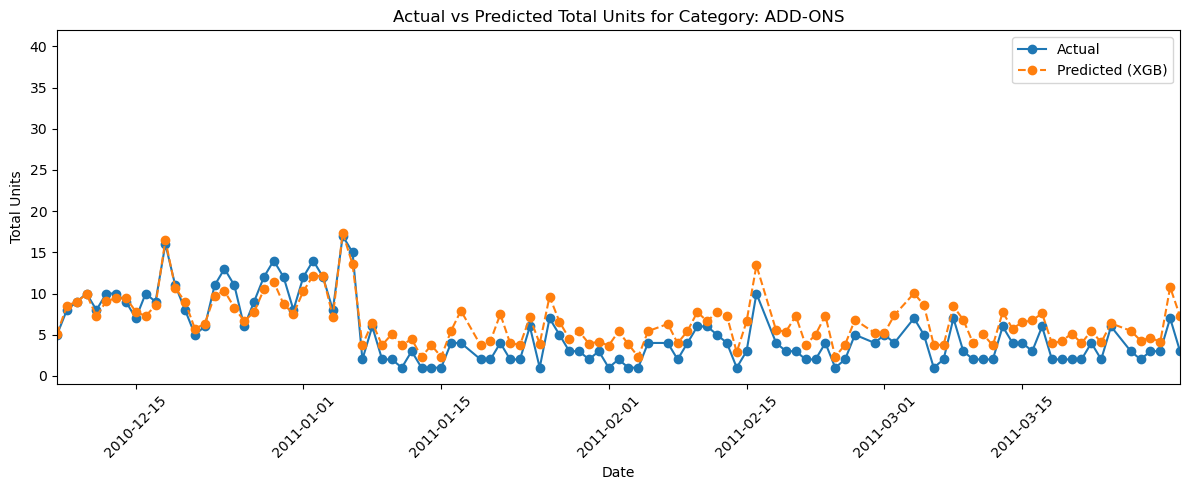

Category: BEVERAGE
XGBoost Model Performance:
R^2 Score: 0.8554086685180664
Mean Absolute Error: 10.562453269958496
Mean Squared Error: 209.6574249267578




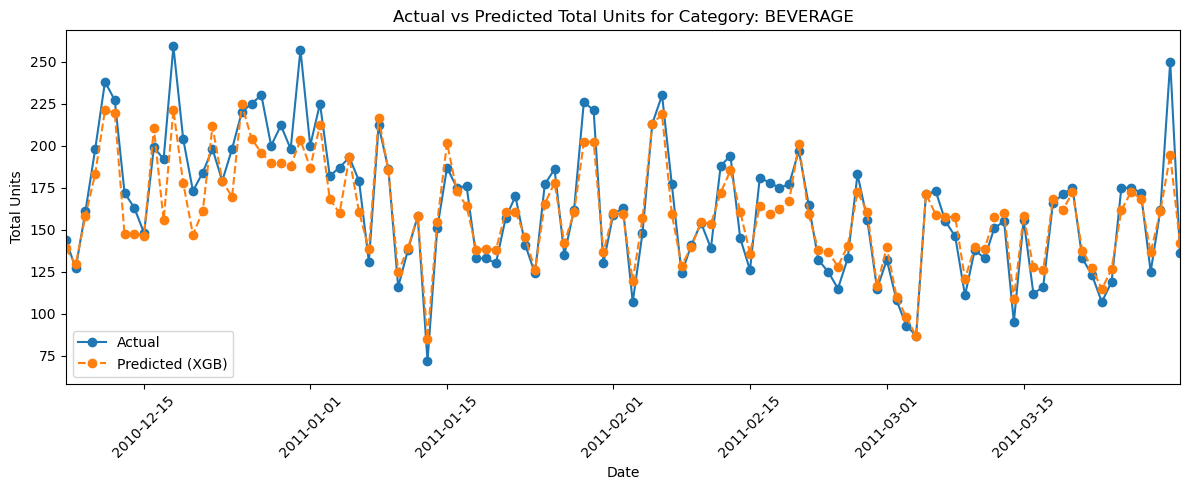

Category: FOOD
XGBoost Model Performance:
R^2 Score: 0.957973301410675
Mean Absolute Error: 5.830012798309326
Mean Squared Error: 68.18919372558594




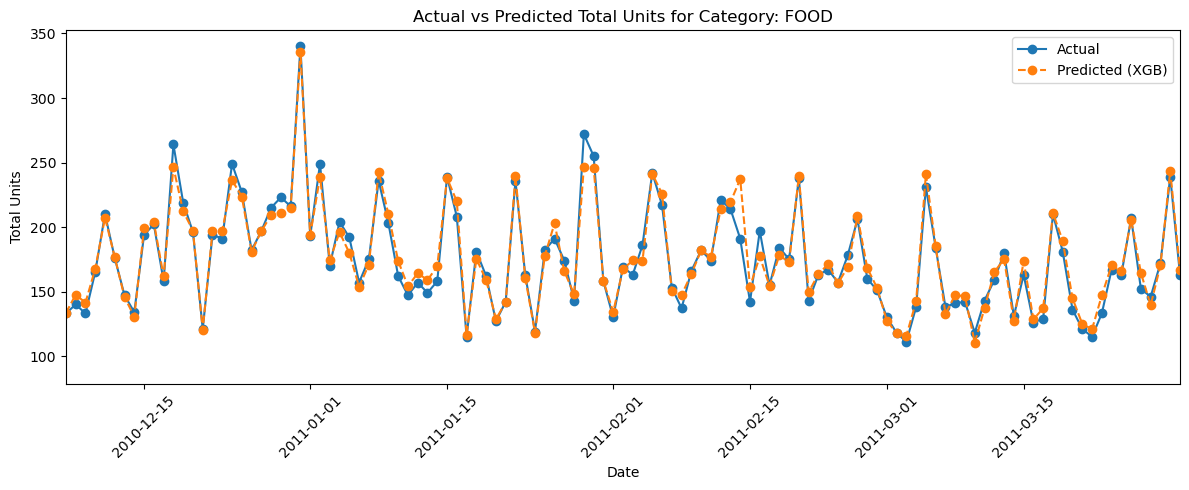

Category: LIQUOR
XGBoost Model Performance:
R^2 Score: 0.6500543355941772
Mean Absolute Error: 7.104815483093262
Mean Squared Error: 140.67359924316406




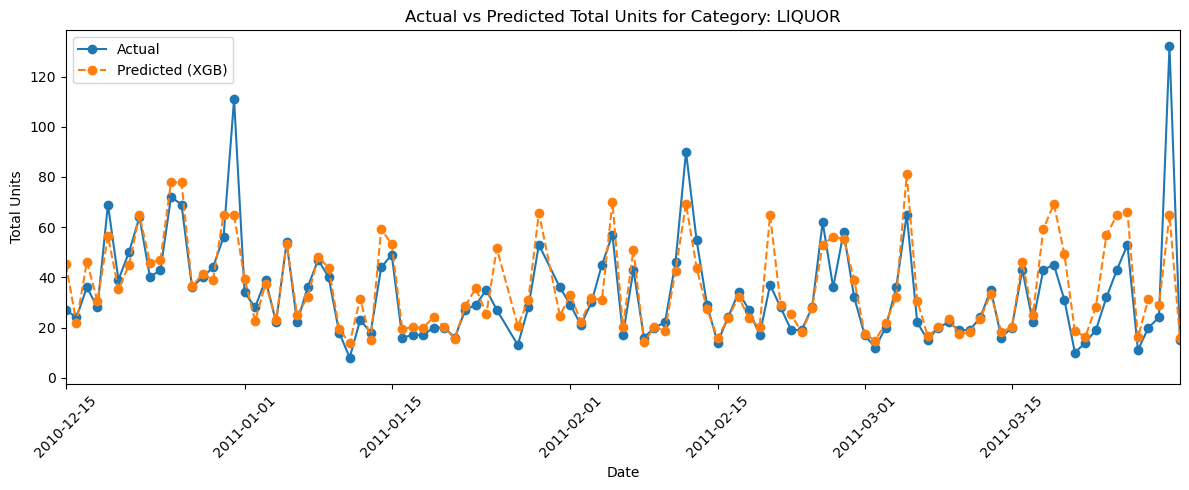

Category: TOBACCO
XGBoost Model Performance:
R^2 Score: 0.6171466112136841
Mean Absolute Error: 9.590513229370117
Mean Squared Error: 129.2752227783203




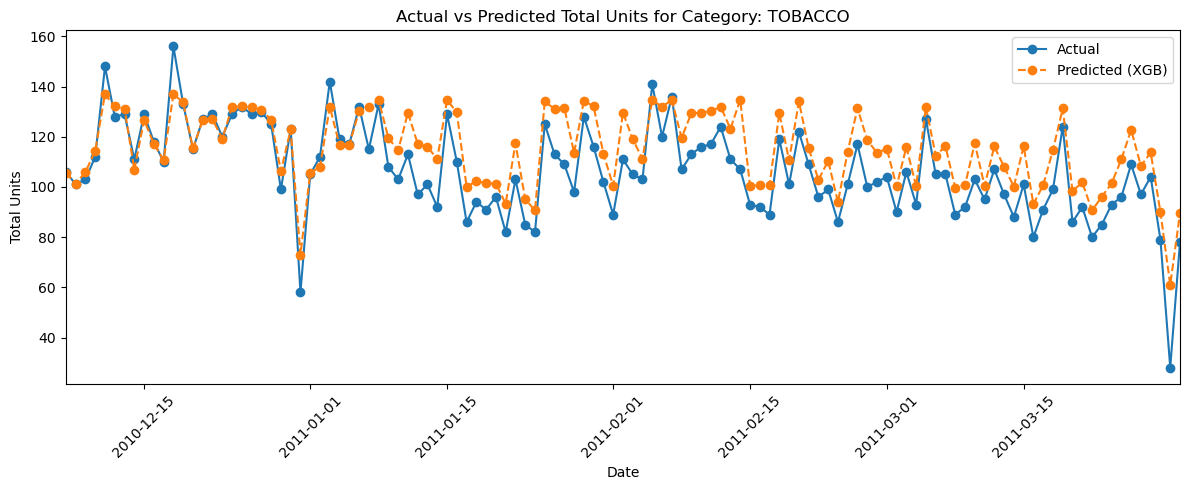

Category: WINES
XGBoost Model Performance:
R^2 Score: -0.01644611358642578
Mean Absolute Error: 1.458693504333496
Mean Squared Error: 4.755191802978516




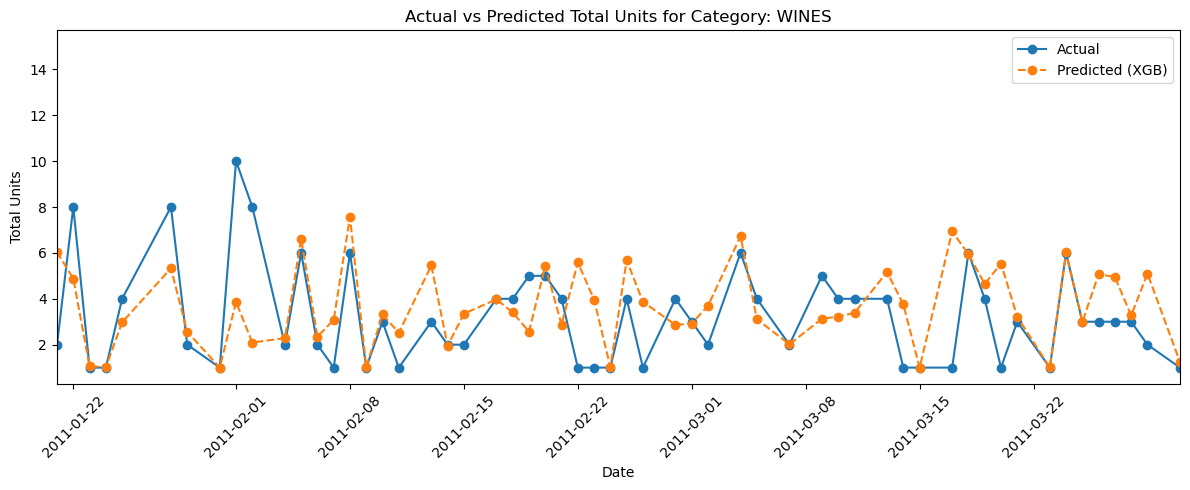

In [58]:
for category, df_cat in daily.groupby('Category'):
    if category == "LIQUOR " or category == "LIQUOR & TPBACCO" or category == "MERCHANDISE" or category == "MISC":
        continue

    print(f"Category: {category}")
    # print(df_cat.head())
    
    X_data, Y_data = df_cat.drop(columns=["Total_Units", "Date", "Category"]), df_cat["Total_Units"]

    x_train, x_test = X_data[:250], X_data[250:]
    y_train, y_test = Y_data[:250], Y_data[250:]

    xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
    xgb.fit(x_train, y_train)
    y_pred_xgb = xgb.predict(x_test)

    print("XGBoost Model Performance:")
    print("R^2 Score:", r2_score(y_test, y_pred_xgb))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
    print("\n")
    # plot actual vs predicted for the test set
    dates = df_cat['Date'].iloc[250:]  # test dates
    plt.figure(figsize=(12,5))
    plt.plot(df_cat["Date"], df_cat["Total_Units"], label='Actual', marker='o', linestyle='-')
    plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Units')
    plt.title(f'Actual vs Predicted Total Units for Category: {category}')
    plt.legend()
    plt.xlim(dates.min(), dates.max())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
